<a href="https://colab.research.google.com/github/expely/Business-Analytics-Labs/blob/main/Assignments/assignment_10_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# IS4487 Week 10 - Assignment

### Outline

Our Goals with this Project:

1. Import and review the data
2. Perform EDA and Clean Data
3. Fit a model
4. Test the accuracy of the model
6.  Use the model to predict on a new dataset (without the target)

<a href="https://colab.research.google.com/github/Stan-Pugsley/is_4487_base/blob/main/Assignments/assignment_10_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Business Case: AdviseInvest
You work on a small team of data analysts at AdviseInvest, a venture-backed startup. The Director of Sales at AdviseInvest has approached your team asking for help solving a staffing problem.

### The Company
The company's mission is to provide tools and support to help ordinary people gain control of their personal finances. The company leverages technology to provide affordable financial advice to a national client base.

Customers who reach AdviseInvest's website go through five steps:

- Open an account.
- Complete a customer profile form with basic information about their background and finances.
- Schedule a free phone conversation with a sales representative during a 1-hour window of time.
- Attend the free phone conversation.
- Buy a financial plan.
- There are three types of financial plans: Beginner, Intermediate, and Advanced. Each is sold at a different price, and there are varying degrees of personalization. After a customer purchases a financial plan, the customer is assigned a financial planner who helps determine the customer's goals and advises the customer on spending decisions.

### The Problem
Some customers are lost at each stage of the process. Steps 3 and 4 are particularly challenging because approximately 50% of those who schedule a phone conversation fail to pick up the call. This leads to inefficiencies from a staffing perspective.

AdviseInvest has 4 sales reps on staff during each particular 1-hour window. Each of the 4 reps is assigned 2 prospective customers per hour, which means that the company schedules a total of 8 phone calls per hour. The calls are outgoing: sales reps call customers who scheduled a phone conversation during that hour window.

Unfortunately, as noted above, many of the customers who scheduled a call do not answer. As a consequence, sales reps are often left underutilized. Moreover, they are underutilized unevenly. For example, it is possible that one sales rep will not do any sales calls during that hour, whereas another will be busy the entire hour with two calls. Sales reps have nothing to do when customers do not answer the scheduled phone call.

### AdviseInvest Data Dictionary


| Variable | Description | Type | Code |
|:---|:---|:---|:---|
| customer_id | Unique customer identifier | Numeric | |
| Answered | Customer response | Binary | 0: customer did not answer scheduled call; 1: customer answered scheduled call |
| Income | Customer income in US dollars | Numeric | |
| Female | Customer gender | Binary | 0: female; 1: male |
| Age | Age in years | Numeric | |
| Job | Nature of job | Categorical | 0 : unemployed; 1 : entry level position; 2 : midlevel position; 3 : management/ self-employed/ highly qualified employee/ officer |
| Num_dependents | Number of people for whom the customer provides maintenance | Numeric | |
| Rent | Customer rents | Binary | 0: no; 1: yes |
| Own_res | Customer owns residence | Binary | 0: no; 1: yes |
| New_car | Recent new car purchase | Binary | New car purchase in the last 3 months: 0: no, 1: yes |
| Chk_acct | Checking account status | Categorical | 0 : no checking account; 1: checking < 200 USD; 2 : 200 < checking < 2000 USD; 3: 2000 < checking < 35000 USD; 4: >= 3500 USD |
| Sav_acct | Average balance in savings account | Categorical | 0 : no savings account; 1 : 100 <= savings < 500 USD; 2 : 500 <= savings < 2000 USD; 3 : 2000 < savings < 35000 USD; 4: >= 3500 USD |
| Num_accts | Number of accounts owned by customer | Numeric | |
| Mobile | Mobile phone | Binary | 0: customer provided non‐mobile phone for follow‐up call; 1: customer provided mobile phone for follow‐up call |
| Product | Type of product purchased after conversation with sales rep | Categorical | 0: customer did not answer call; 1: customer answered but did not purchase a product; 2: customer answered and purchased Beginner plan; 3: customer answered and purchased Intermediate plan; 4: customer answered and purchased Advanced plan |

### Load Libraries

Import the libraries you will need, such as:
- Pandas
- Sklearn
- Matplotlib


In [126]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
import seaborn as sns

## Step 1: Initial Data Understanding

### Do the following:
 - Import data from the AdviseInvest historical dataset into a dataframe (in GitHub go to the DataSets folder and look for `adviseinvest_historical_data.csv`)
 - Describe or profile the dataframe
 - Look for any outliers, missing values, or duplicates

In [127]:
# Load the dataset
url = 'https://raw.githubusercontent.com/Stan-Pugsley/is_4487_base/refs/heads/main/DataSets/adviseinvest_historical_data.csv'
df = pd.read_csv(url)

In [128]:
# View the datatypes
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29504 entries, 0 to 29503
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   customer_id     29504 non-null  int64  
 1   answered        29504 non-null  int64  
 2   income          29504 non-null  int64  
 3   female          29504 non-null  object 
 4   age             29504 non-null  int64  
 5   job             29504 non-null  int64  
 6   num_dependents  29504 non-null  int64  
 7   rent            29504 non-null  int64  
 8   own_res         29504 non-null  int64  
 9   new_car         29502 non-null  float64
 10  chk_acct        29504 non-null  int64  
 11  sav_acct        29504 non-null  int64  
 12  num_accts       29504 non-null  int64  
 13  mobile          29504 non-null  int64  
 14  product         29504 non-null  int64  
dtypes: float64(1), int64(13), object(1)
memory usage: 3.4+ MB


In [129]:
# Describe the data
df.describe()

,customer_id,answered,income,age,job,num_dependents,rent,own_res,new_car,chk_acct,sav_acct,num_accts,mobile,product
count,29504.000000,29504.000000,29504.000000,29504.000000,29504.000000,29504.000000,29504.000000,29504.000000,29502.000000,29504.000000,29504.000000,29504.000000,29504.000000,29504.000000
mean,14850.475563,0.546638,33766.893303,34.773454,1.915401,1.140998,0.210412,0.681128,0.240797,1.468547,0.956616,2.458345,0.091106,1.535792
std,8517.254310,0.497829,29379.202710,11.369865,0.658183,0.348025,0.407608,0.466047,0.427575,1.234727,1.483946,19.497380,0.287765,1.625916
min,99.000000,0.000000,-65600.000000,19.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,7474.750000,0.000000,13550.000000,26.000000,2.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000,0.000000
50%,14850.500000,1.000000,23310.000000,32.000000,2.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,2.000000,0.000000,1.000000
75%,22226.250000,1.000000,41690.000000,40.000000,2.000000,1.000000,0.000000,1.000000,0.000000,3.000000,2.000000,3.000000,0.000000,3.000000
max,29602.000000,1.000000,159450.000000,132.000000,3.000000,2.000000,1.000000,1.000000,1.000000,3.000000,4.000000,3345.000000,1.000000,4.000000


## Step 2: Data Preparation

### 2.1: Data Cleanup
- Check for and remove any outliers
- Consider fixing any missing data (should you delete the record or impute the value?)
- Clean up the data and put it in a new dataframe named "df_clean"


In [130]:
# Remove outliers
df_clean = df.copy()
df_clean = df_clean[df_clean['age'].between(19, 100)]
df_clean = df_clean[df_clean['income'] >= 0]
df_clean = df_clean[df_clean['num_accts'] < 20]

In [131]:
# Drop new cars
df_clean = df_clean.dropna(subset=['new_car'])

### 2.2: Standardize variables

 - Change "answered" to a boolean (true/false) type
 - Convert any variables that should be an integer into an integer

In [132]:
# Convert answered to boolean
df_clean['answered'] = df_clean['answered'].astype('bool')

In [133]:
# Convert new_car to integer
df_clean['new_car'] = df_clean['new_car'].astype(int)

### 2.3 Convert variables to categorical

- Find at least 8 variables that would be appropriate to convert to categories

In [134]:
# Convert categorical integer columns
df_clean['job'] = df_clean['job'].astype('category')
df_clean['product'] = df_clean['product'].astype('category')

# Convert columns with limited possible values with an order to ordinal categorical columns
df_clean['chk_acct'] = pd.Categorical(df_clean['chk_acct'], categories=[0, 1, 2, 3, 4], ordered=True)
df_clean['sav_acct'] = pd.Categorical(df_clean['sav_acct'], categories=[0, 1, 2, 3, 4], ordered=True)

# Convert binary columns (0/1) to binary categorical
df_clean['female'] = df_clean['female'].replace({'M': 1, 'F': 0, 'm': 1, 'f': 0})
df_clean['female'] = df_clean['female'].astype('category')
df_clean['rent'] = df_clean['rent'].astype('category')
df_clean['own_res'] = df_clean['own_res'].astype('category')
df_clean['new_car'] = df_clean['new_car'].astype('category')
df_clean['mobile'] = df_clean['mobile'].astype('category')

# Check updated data types
print("\nUpdated dtypes:\n", df_clean.dtypes)


Updated dtypes:
 customer_id          int64
answered              bool
income               int64
female            category
age                  int64
job               category
num_dependents       int64
rent              category
own_res           category
new_car           category
chk_acct          category
sav_acct          category
num_accts            int64
mobile            category
product           category
dtype: object


# Step 3: Exploratory Data Analysis (EDA)

### Do the following:
- Explore the relationships between the target and independent variables
- Create at least five charts to show the relationships, using different chart types that are approriate to the analysis
- Ensure that all charts are clearly labeled and formatted



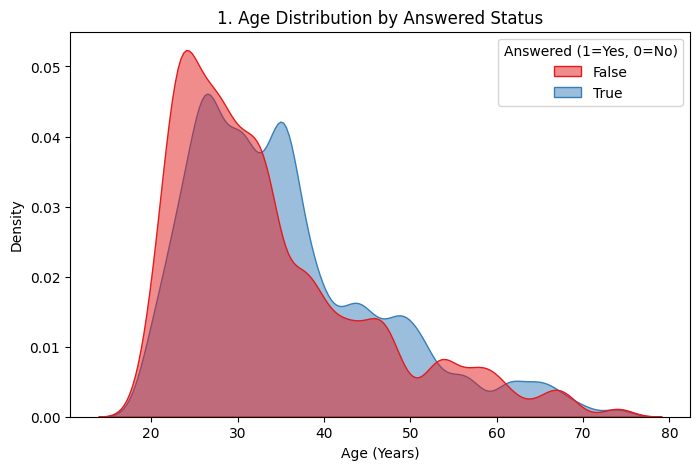

In [135]:
# KDE Plot
plt.figure(figsize=(8, 5))
sns.kdeplot(data=df_clean, x='age', hue='answered', fill=True, common_norm=False, palette='Set1', alpha=0.5)
plt.title('1. Age Distribution by Answered Status')
plt.xlabel('Age (Years)')
plt.ylabel('Density')
# Update legend labels for clarity
legend = plt.gca().get_legend()
if legend:
    legend.set_title('Answered (1=Yes, 0=No)')
plt.show()

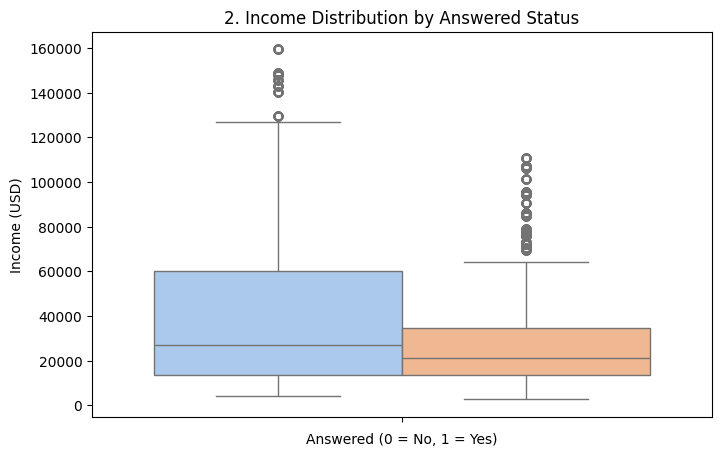

In [136]:
# Boxplot
plt.figure(figsize=(8, 5))
sns.boxplot(data=df_clean, hue='answered', y='income', palette='pastel', legend=False)
plt.title('2. Income Distribution by Answered Status')
plt.xlabel('Answered (0 = No, 1 = Yes)')
plt.ylabel('Income (USD)')
plt.show()

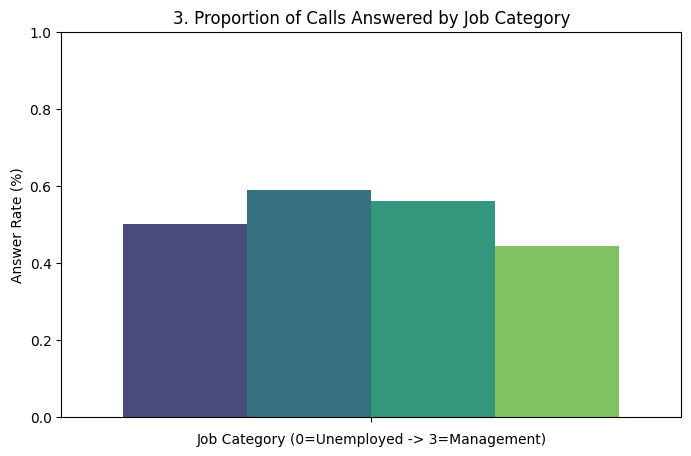

In [137]:
# Barplot
plt.figure(figsize=(8, 5))
sns.barplot(data=df_clean, hue='job', y='answered', errorbar=None, palette='viridis', legend=False)
plt.title('3. Proportion of Calls Answered by Job Category')
plt.xlabel('Job Category (0=Unemployed -> 3=Management)')
plt.ylabel('Answer Rate (%)')
plt.ylim(0, 1)
plt.show()

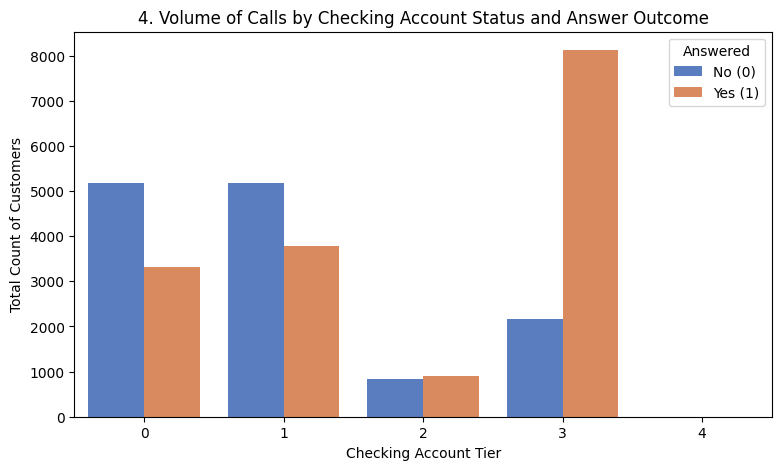

In [138]:
# Grouped Countplot
plt.figure(figsize=(9, 5))
sns.countplot(data=df_clean, x='chk_acct', hue='answered', palette='muted')
plt.title('4. Volume of Calls by Checking Account Status and Answer Outcome')
plt.xlabel('Checking Account Tier')
plt.ylabel('Total Count of Customers')
plt.legend(title='Answered', labels=['No (0)', 'Yes (1)'])
plt.show()

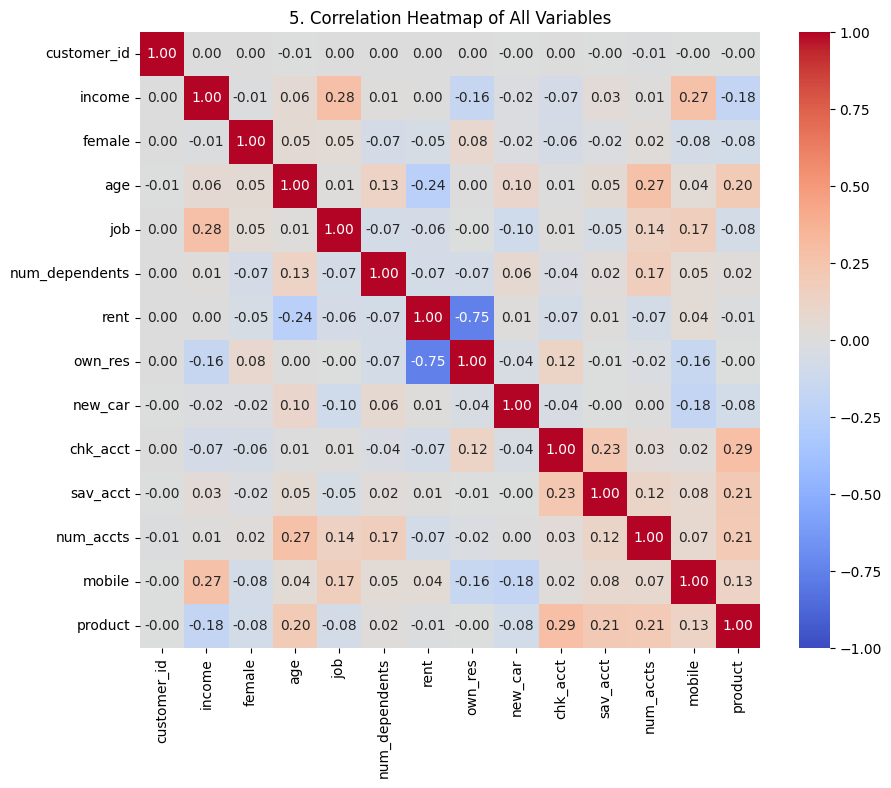

In [139]:
# Correl Heatmap
plt.figure(figsize=(10, 8))
numeric_cols = df_clean.select_dtypes(include=['number', 'category']).apply(lambda x: x.cat.codes if x.dtype.name == 'category' else x)
corr = numeric_cols.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('5. Correlation Heatmap of All Variables')
plt.show()

## Step 4: Modeling

### 4.1: Calculate the base probability of answering

If we use no model at all, how good is our chance of predicting someone leaving?  Use a calculation to find the chances of someone leaving.

In [140]:
# Default Chance that someone answers
df_clean['answered'].mean()

np.float64(0.546613329717269)

### 4.2: Split the training and testing datasets

- split df_clean using train_test_split function
- all variables except answered should be in the x variable
- answered is in the y variable


In [141]:
# Select features and target
# Don't include product because it's a basis for answered
X = df_clean.drop(['answered', 'product', 'customer_id'], axis=1)
y = df_clean['answered']

# Create train/test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Check dimensions
X_train.shape, X_test.shape

((23598, 12), (5900, 12))

### 4.3: Create a Decision Tree
- Use all available attributes (except those that were eliminated in step 3)
- It is recommended to use the type "entropy" and a max_depth of 4

In [142]:
# Initialize classifier
clf = DecisionTreeClassifier(criterion='entropy', max_depth=4, random_state=42)

# Train model on training data
clf.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=4, random_state=42)

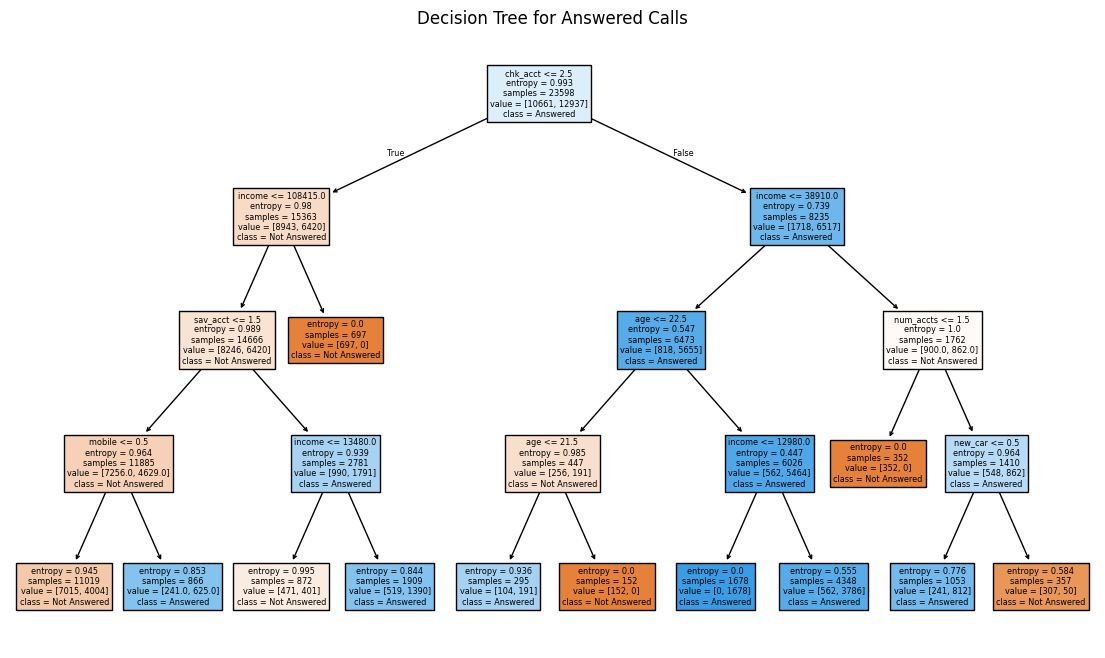

In [143]:
# Plot decision tree
plt.figure(figsize=(14, 8))
plot_tree(clf, feature_names=X.columns, class_names=['Not Answered', 'Answered'], filled=True)
plt.title("Decision Tree for Answered Calls")
plt.show()

### 4.4: What is the accuracy?

This should be better than the base probability, or you have failed in your objective

In [144]:
# Predict on test set
y_pred = clf.predict(X_test)

# Accuracy
acc = accuracy_score(y_test, y_pred)
print("Test Accuracy:", acc)

Test Accuracy: 0.7359322033898306


### 4.5: Create a confusion matrix

This will show false positives, true positives, etc.

In [145]:
# Confusion matrix
confusion_matrix = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", confusion_matrix)

Confusion Matrix:
 [[2268  445]
 [1113 2074]]


Create a more visual, interpretable version of the matrix

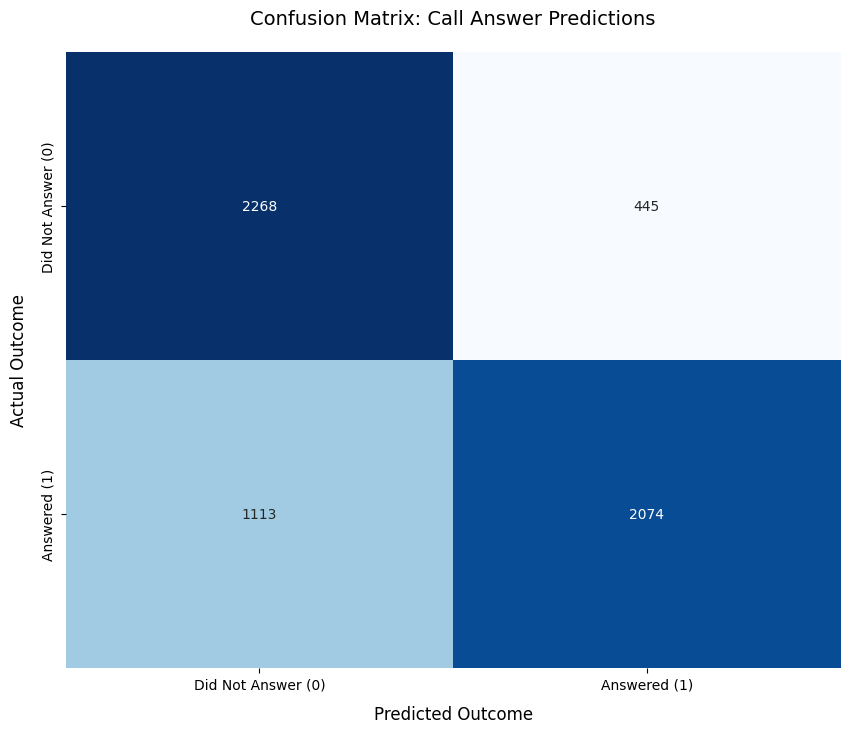

In [146]:
# Correl Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(
    confusion_matrix,
    annot=True,
    fmt='d',
    cmap='Blues',
    cbar=False,
    xticklabels=['Did Not Answer (0)', 'Answered (1)'],
    yticklabels=['Did Not Answer (0)', 'Answered (1)']
)
plt.title('Confusion Matrix: Call Answer Predictions', fontsize=14, pad=20)
plt.xlabel('Predicted Outcome', fontsize=12, labelpad=10)
plt.ylabel('Actual Outcome', fontsize=12, labelpad=10)
plt.show()

# Step 5: Evaluate the Model

**Assumptions**

One of the simplifying assumptions we will make in this project is that all the customers who answer the phone will purchase a product. (This assumption is actually verified by the data.) To model "answered" in this case is therefore equivalent to modeling "purchased."

There are costs and benefits in this case. We will assume that customers purchase a product for 100 dollars. This was the average cost of AdviseInvest products, according to the Director of Sales.  Also, as we learned in the interview, the agent time to make the sale is worth 25 dollars. Profit would therefore be \$75 dollars for an answered call and a purchase. In sum:

**Benefit**: True positive. The customer is predicted to answer, does answer, and purchases a product for 100 dollars for a profit of 100 - 25 = 75.

**Cost**: False positive. The customer is predicted to answer, but does not answer, so there is a loss of 25. (We assume the agent cannot schedule another call at the last minute, or spends the entire time slot trying to make the call.)

When you create a calculation you can use:
- True answered * 75 -> These people purchased
- False answered * 25 -> You can't schedule another call

For this exercise, we propose that customers who are not predicted to answer will not be called, so there would be no benefits and no costs for them.  

### 5.1 Calculate the Profit Using the Model

In [147]:
# Create a new profit dataframe
profit_df = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred
})

# True Positive
condition_tp = (profit_df['Predicted'] == 1) & (profit_df['Actual'] == 1)

# False Positive
condition_fp = (profit_df['Predicted'] == 1) & (profit_df['Actual'] == 0)

# Apply Rules
profit_df['Profit'] = 0
profit_df.loc[condition_tp, 'Profit'] = 75
profit_df.loc[condition_fp, 'Profit'] = -25
total_profit = profit_df['Profit'].sum()
print(f"Total profit: ${total_profit}")

Total profit: $144425


### 5.2 Compare to the Default Profit

How much profit (revenue - costs) could be expected if all customers are called? We can consider this a baseline case for profit since it does not require a model.

In other words, to calculate profit in this baseline scenario treat the customers who answer as true positives treat the customers who do not answer as false positives.

In [148]:
# Calculate Baseline Profit
total_customers = len(y_test)
baseline_tp = y_test.sum()
baseline_fp = total_customers - baseline_tp
baseline_profit = (baseline_tp * 75) + (baseline_fp * -25)
print(f"Baseline profit: ${baseline_profit}")

Baseline profit: $171200


### 5.3 Tune the Model
- Adjust the size or shape of the tree, then test the accuracy
- Keep changing these parameters until you end up with a tree with accuracy that is better than the initial model

In [149]:
# Initialize classifier
clf_new = DecisionTreeClassifier(criterion='entropy', max_depth=10, random_state=42)

# Train model on training data
clf_new.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=10, random_state=42)

In [150]:
# Predict on test set
y_pred = clf_new.predict(X_test)

# Accuracy
acc = accuracy_score(y_test, y_pred)
print("Test Accuracy:", acc)

Test Accuracy: 0.8403389830508474


### 5.4 Apply the Model to New Customers
- Import the "adviseinvest_new_customer_data.csv" file
- Using the tree model, predict each customer for the target variable  by feeding the new customer data into the model

In [151]:
# Load the new dataset
url = 'https://raw.githubusercontent.com/Stan-Pugsley/is_4487_base/refs/heads/main/DataSets/adviseinvest_new_customer_data.csv'
df_new_cust = pd.read_csv(url)

# Convert categorical integer columns
df_new_cust['job'] = df_new_cust['job'].astype('category')

# Convert columns with limited possible values with an order to ordinal categorical columns
df_new_cust['chk_acct'] = pd.Categorical(df_new_cust['chk_acct'], categories=[0, 1, 2, 3, 4], ordered=True)
df_new_cust['sav_acct'] = pd.Categorical(df_new_cust['sav_acct'], categories=[0, 1, 2, 3, 4], ordered=True)

# Convert binary columns (0/1) to binary categorical
df_new_cust['female'] = df_new_cust['female'].replace({'M': 1, 'F': 0, 'm': 1, 'f': 0})
df_new_cust['female'] = df_new_cust['female'].astype('category')
df_new_cust['rent'] = df_new_cust['rent'].astype('category')
df_new_cust['own_res'] = df_new_cust['own_res'].astype('category')
df_new_cust['new_car'] = df_new_cust['new_car'].astype('category')
df_new_cust['mobile'] = df_new_cust['mobile'].astype('category')

In [152]:
# Predict New Customer Data
X_new = df_new_cust.copy()[X.columns.tolist()]
new_predictions = clf_new.predict(X_new)
df_new_cust['predicted_answered'] = new_predictions

df_new_cust.head()

,income,female,age,job,num_dependents,rent,own_res,new_car,chk_acct,sav_acct,num_accts,mobile,customer_id,predicted_answered
0,30010,0,40,2,1,1,0,0,1,0,3,0,H1597,False
1,30510,0,54,2,1,0,1,0,0,0,2,0,P1446,False
2,12880,0,48,2,2,0,1,0,0,1,4,0,E1492,False
3,15530,0,44,2,1,0,1,0,0,0,2,0,W5143,False
4,46230,0,40,3,1,0,1,0,3,1,2,0,W4927,False


# Step 6: Conclusion
### 6.1: Did we improve our profit using the model?  

Write your conclusion notes below:

- Not really, because we could not accurately predict enough people's profits, it was hard to say just by a raw number that we increased the profit. We definitely increased the percentage that we guessed correctly, but in pure $ amount, it seems unlikely.

### 6.2: How could the model be utilized by the business?

Write your recommendations below:  🔧

The biggest thing that the businese can utilize is to create a better daily call list. Now that we have a lot of the customers information we can better predict whether or not they will actually answer the call, so we can more efficiently distribute our workers to call those who are more likely to pick up. Another thing that the business can do is target those individuals from the get-go of whether they will pick up or not. If we never interact with the people who are unlikely to pickup, we will increase the number of calls picked up by a lot!

## Submission Instructions
✅ Checklist:
- All code cells run without error
- All markdown responses are complete
- Submit on Canvas as instructed

In [153]:
!jupyter nbconvert --to html "assignment_10_classification.ipynb"

[NbConvertApp] Converting notebook assignment_10_classification.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 7 image(s).
[NbConvertApp] Writing 990482 bytes to assignment_10_classification.html
